 # 01 — Initial Functional Exploration of Gaia XP Sampled Spectra



 This notebook performs an initial functional data exploration of sampled

 Gaia XP spectra for the binary vs non-binary classification task.



 Main goals:

 - inspect the structure and quality of the sampled spectra data;

 - visualize example spectra;

 - compute functional mean and standard deviation curves;

 - compare class-wise mean spectra;

 - inspect mean difference curves between classes;

 - explore correlation structure across wavelengths;

 - examine first and second derivatives of spectra.



 The notebook is descriptive and exploratory only. No predictive models are

 trained here.



 Data:

 - sampled spectra from `xp_sampled_spectra.csv`;

 - labels from the same file if available, otherwise from `og_xp.csv`.



 Main exported outputs:

 - dataset_summary.csv

 - class_mean_spectra.csv

 - derivative_summary_by_class.csv

 - top_wavelength_differences.csv

 - spectrum_descriptors.csv

 - fig_example_spectra.svg

 - fig_mean_std_overall.svg

 - fig_class_mean_spectra.svg

 - fig_class_mean_difference_l2.svg

 - fig_correlation_heatmap.svg

 - fig_first_derivative_means.svg

 - fig_second_derivative_means.svg

In [19]:
from __future__ import annotations

import warnings
from datetime import datetime
from pathlib import Path
from typing import Optional, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.figure import Figure

# Ignore warnings in the exploratory notebook output so that printed summaries
# and figures remain readable.
warnings.filterwarnings("ignore")

# Fixed seed ensures that the randomly selected example spectra are always the
# same when the notebook is rerun.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)



 ## 1. Configuration

In [20]:
# Base folder that contains input data files. The notebook assumes that the
# working directory contains an `og_data` folder.
BASE_DIR = Path.cwd() / "og_data"

# Output folder for all generated CSV files and SVG figures. The folder is
# created automatically if it does not already exist.
OUT_DIR = Path.cwd() / "results" / "01_initial_data_exploration"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Timestamp is stored in the dataset summary so that exported results can be
# traced back to the notebook run.
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M")

# Candidate locations for sampled spectra. Keeping this as a list makes it easy
# to add alternative filenames later without changing the loading logic.
SAMPLED_CANDIDATES = [
    BASE_DIR / "xp_sampled_spectra.csv",
]

# Candidate locations for labels. This file is used only if the sampled spectra
# file does not already contain a label column.
LABEL_CANDIDATES = [
    BASE_DIR / "og_xp.csv",
]

# Main representation used in plots, derivatives, and correlation analysis.
# - "l2" uses row-wise L2-normalized spectra and is the default thesis version.
# - "raw" uses the original flux values without row-wise normalization.
MAIN_REPRESENTATION = "l2"

# Number of randomly selected example spectra to draw from each class.
N_EXAMPLE_PER_CLASS = 8

# Step size used when plotting the correlation heatmap. A value of 3 plots every
# third wavelength and makes the heatmap smaller and easier to render.
CORR_PLOT_STEP = 3



 ## 2. Plot style for thesis-ready figures

In [21]:
# Main figure colors. The same palette is reused across all plots to keep the
# thesis figures visually consistent.
COLOR_PRIMARY = "#104A7E"
COLOR_SECONDARY = "#78003F"
COLOR_DARK = "#0D1530"
COLOR_LIGHT = "#D9D9D9"
COLOR_TEXT = "#222222"

# Global Matplotlib settings. These values control fonts, axis styling, colors,
# and background colors for every figure created below.
plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 11,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "axes.edgecolor": "#444444",
        "axes.linewidth": 0.8,
        "axes.labelcolor": COLOR_TEXT,
        "xtick.color": COLOR_TEXT,
        "ytick.color": COLOR_TEXT,
        "text.color": COLOR_TEXT,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    }
)


def apply_clean_axes(ax: plt.Axes, add_grid: bool = False) -> None:
    """Apply a clean thesis-ready axis style to a Matplotlib axis.

    The function removes the top and right spines from the plot. This gives the
    figures a lighter style and avoids unnecessary visual clutter. If requested,
    it also adds a subtle horizontal grid.

    Parameters
    ----------
    ax:
        Matplotlib axis object to be styled.
    add_grid:
        Whether to add a light dashed grid on the y-axis.
    """
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if add_grid:
        ax.grid(
            True,
            axis="y",
            linestyle="--",
            linewidth=0.6,
            alpha=0.5,
            color=COLOR_LIGHT,
        )
    else:
        ax.grid(False)


def show_and_save(fig: Figure, path: Path) -> None:
    """Show a figure, save it as an SVG file, and close it.

    This replaces a separate final figure-saving block. Each figure is now saved
    directly after it is displayed, which avoids duplicated plotting code and
    makes it easier to connect each figure with its output filename.

    Parameters
    ----------
    fig:
        Matplotlib figure object to display and save.
    path:
        Full output path for the saved SVG file.
    """
    fig.tight_layout()
    plt.show()
    fig.savefig(path, format="svg", bbox_inches="tight", facecolor="white")
    plt.close(fig)



 ## 3. Helper functions

In [22]:
def find_first_existing(paths: Sequence[Path]) -> Optional[Path]:
    """Find the first existing file path from a list of candidates.

    This is used for input files because the same dataset may sometimes be saved
    under slightly different names or locations. The function checks paths in
    order and returns the first one that exists.

    Parameters
    ----------
    paths:
        Candidate file paths to check.

    Returns
    -------
    Optional[Path]
        The first existing path, or ``None`` if none of the candidates exist.
    """
    for path in paths:
        path = Path(path)
        if path.exists():
            return path
    return None


def detect_id_column(df: pd.DataFrame) -> str:
    """Detect the source identifier column in a dataframe.

    The Gaia object identifier is needed to merge spectra with labels and to
    preserve object-level information in exported descriptor tables. The function
    searches for common ID column names.

    Parameters
    ----------
    df:
        Dataframe whose columns should be searched.

    Returns
    -------
    str
        Name of the detected ID column.

    Raises
    ------
    ValueError
        If no suitable ID column is found.
    """
    candidates = ["source_id", "SOURCE_ID", "id", "ID"]

    for col in candidates:
        if col in df.columns:
            return col

    raise ValueError("Could not find an ID column such as `source_id`.")


def detect_label_column(df: pd.DataFrame) -> Optional[str]:
    """Detect a likely binary class label column in a dataframe.

    Labels are expected to describe whether the object belongs to the binary or
    non-binary class. The function checks several common label column names used
    in earlier versions of the dataset.

    Parameters
    ----------
    df:
        Dataframe whose columns should be searched.

    Returns
    -------
    Optional[str]
        Name of the detected label column, or ``None`` if no label column is
        found.
    """
    candidates = [
        "y",
        "label",
        "target",
        "class",
        "binary_label",
        "is_binary",
        "binary",
        "labels",
    ]

    for col in candidates:
        if col in df.columns:
            return col

    return None


def coerce_binary_labels(series: pd.Series) -> pd.Series:
    """Convert numeric or text class labels to integer values 0 and 1.

    The thesis convention is:
    - ``0`` for non-binary objects;
    - ``1`` for binary objects.

    The function first handles already numeric 0/1 labels. If labels are textual,
    it maps common class names to 0 and 1. If exactly two unknown label values are
    present, it falls back to alphabetical ordering. This fallback is included
    only to prevent failure on simple two-class files with different naming.

    Parameters
    ----------
    series:
        Label column from the input dataframe.

    Returns
    -------
    pd.Series
        Integer binary labels.

    Raises
    ------
    ValueError
        If labels cannot be safely converted to two classes.
    """
    labels = series.copy()

    if pd.api.types.is_numeric_dtype(labels):
        values = sorted(pd.Series(labels).dropna().unique().tolist())
        if set(values).issubset({0, 1}):
            return labels.astype(int)

    labels_str = labels.astype(str).str.strip().str.lower()
    mapping = {
        "0": 0,
        "1": 1,
        "false": 0,
        "true": 1,
        "non-binary": 0,
        "non_binary": 0,
        "nonbinary": 0,
        "binary": 1,
        "single": 0,
    }
    mapped = labels_str.map(mapping)

    if mapped.isna().any():
        unique_labels = sorted(labels_str.dropna().unique().tolist())
        if len(unique_labels) != 2:
            raise ValueError(
                "Could not safely coerce labels to binary. "
                f"Unique values: {unique_labels}"
            )

        # Fallback is used only when exactly two unknown classes are present.
        fallback_map = {unique_labels[0]: 0, unique_labels[1]: 1}
        mapped = labels_str.map(fallback_map)

    return mapped.astype(int)


def detect_flux_columns(df: pd.DataFrame) -> list[str]:
    """Detect spectral flux columns and return them in wavelength order.

    The sampled spectra can be stored with either:
    - ``wl_`` columns, where the suffix is the wavelength value;
    - ``flux_`` columns, where the suffix is the grid index.

    Sorting is important because all later operations assume that columns follow
    the physical wavelength order.

    Parameters
    ----------
    df:
        Dataframe containing spectral measurements.

    Returns
    -------
    list[str]
        Ordered list of spectral column names.

    Raises
    ------
    ValueError
        If no spectral columns are detected.
    """
    cols = list(df.columns)

    wl_style = [col for col in cols if str(col).startswith("wl_")]
    if wl_style:
        return sorted(wl_style, key=lambda col: float(str(col).replace("wl_", "")))

    flux_style = [col for col in cols if str(col).startswith("flux_")]
    if flux_style:

        def flux_key(name: str) -> int:
            """Extract the numeric index from a flux column name.

            Non-standard names are placed at the end by returning a very large
            number. This keeps the function robust to occasional extra columns.
            """
            try:
                return int(str(name).replace("flux_", ""))
            except ValueError:
                return 10**9

        return sorted(flux_style, key=flux_key)

    raise ValueError("Could not find spectral columns like `wl_336` or `flux_0`.")


def build_wavelength_axis(flux_cols: Sequence[str]) -> np.ndarray:
    """Build the wavelength or index axis from spectral column names.

    For ``wl_`` columns, the numeric suffix is interpreted as the wavelength in
    nanometres. For ``flux_`` columns, no physical wavelength is encoded, so the
    function uses a simple integer index axis.

    Parameters
    ----------
    flux_cols:
        Ordered spectral column names.

    Returns
    -------
    np.ndarray
        Wavelength values or integer grid indices.

    Raises
    ------
    ValueError
        If column names do not follow a supported format.
    """
    if all(str(col).startswith("wl_") for col in flux_cols):
        return np.array(
            [float(str(col).replace("wl_", "")) for col in flux_cols],
            dtype=float,
        )

    if all(str(col).startswith("flux_") for col in flux_cols):
        return np.arange(len(flux_cols), dtype=float)

    raise ValueError("Could not build wavelength axis.")


def l2_row_normalize(x: np.ndarray, eps: float = 1e-20) -> np.ndarray:
    """Apply row-wise L2 normalization to spectra.

    Each spectrum is divided by its own Euclidean norm. This preserves the shape
    of the spectrum while reducing the effect of overall flux scale differences
    between objects.

    Parameters
    ----------
    x:
        Two-dimensional array of spectra with shape ``n_objects x n_wavelengths``.
    eps:
        Small threshold used to avoid division by zero.

    Returns
    -------
    np.ndarray
        L2-normalized spectra with the same shape as the input array.
    """
    row_norm = np.linalg.norm(x, axis=1, keepdims=True)
    return np.divide(x, row_norm, out=np.zeros_like(x), where=row_norm > eps)


def compute_first_derivative(
    x: np.ndarray,
    wavelengths: np.ndarray,
) -> np.ndarray:
    """Compute the first numerical derivative of each spectrum.

    The derivative is calculated along the wavelength axis. It approximates how
    quickly the spectral flux changes between neighbouring wavelengths.

    Parameters
    ----------
    x:
        Spectral data matrix with one object per row.
    wavelengths:
        Wavelength grid used as spacing for the numerical derivative.

    Returns
    -------
    np.ndarray
        First derivative matrix with the same shape as ``x``.
    """
    return np.gradient(x, wavelengths, axis=1)


def compute_second_derivative(
    x: np.ndarray,
    wavelengths: np.ndarray,
) -> np.ndarray:
    """Compute the second numerical derivative of each spectrum.

    The second derivative describes changes in the slope of the spectrum. It is
    useful for exploratory inspection of curvature and local shape differences
    between the two classes.

    Parameters
    ----------
    x:
        Spectral data matrix with one object per row.
    wavelengths:
        Wavelength grid used as spacing for the numerical derivative.

    Returns
    -------
    np.ndarray
        Second derivative matrix with the same shape as ``x``.
    """
    first_derivative = np.gradient(x, wavelengths, axis=1)
    return np.gradient(first_derivative, wavelengths, axis=1)



 ## 4. Load and prepare data

In [23]:
# Locate the sampled spectra file and the optional separate label file.
sampled_path = find_first_existing(SAMPLED_CANDIDATES)
label_path = find_first_existing(LABEL_CANDIDATES)

if sampled_path is None:
    raise FileNotFoundError("Could not find `xp_sampled_spectra.csv`.")

print("Sampled spectra file:", sampled_path)
print("Label file:", label_path if label_path is not None else "not needed / not found")

# Load sampled spectra and detect the key columns needed for analysis.
sampled_df = pd.read_csv(sampled_path)
print("Loaded sampled_df shape:", sampled_df.shape)

sampled_id_col = detect_id_column(sampled_df)
sampled_label_col = detect_label_column(sampled_df)
flux_cols = detect_flux_columns(sampled_df)

print("ID column:", sampled_id_col)
print("Label column in sampled file:", sampled_label_col)
print("Number of spectral columns:", len(flux_cols))
print("First 5 spectral columns:", flux_cols[:5])

# If labels are already included in the sampled spectra file, use them directly.
# Otherwise, load the label file and merge labels by source_id.
if sampled_label_col is not None:
    work_df = sampled_df[[sampled_id_col, sampled_label_col] + flux_cols].copy()
    work_df = work_df.rename(
        columns={sampled_id_col: "source_id", sampled_label_col: "y"}
    )
else:
    if label_path is None:
        raise FileNotFoundError(
            "No label column found in sampled spectra file and no label file "
            "available."
        )

    label_df = pd.read_csv(label_path)
    label_id_col = detect_id_column(label_df)
    label_col = detect_label_column(label_df)

    if label_col is None:
        raise ValueError("Could not find a label column in label file.")

    label_df = label_df[[label_id_col, label_col]].copy()
    label_df = label_df.rename(columns={label_id_col: "source_id", label_col: "y"})

    work_df = sampled_df[[sampled_id_col] + flux_cols].copy()
    work_df = work_df.rename(columns={sampled_id_col: "source_id"})
    work_df = work_df.merge(label_df, on="source_id", how="inner")

# Remove rows without labels and convert labels to the 0/1 convention.
work_df = work_df.dropna(subset=["y"]).copy()
work_df["y"] = coerce_binary_labels(work_df["y"])

# Remove rows with missing spectral values because derivative and correlation
# calculations require complete spectra.
before = len(work_df)
work_df = work_df.dropna(subset=flux_cols).reset_index(drop=True)
after = len(work_df)

print(f"Dropped rows with missing labels/spectra: {before - after}")
print("Final dataset shape:", work_df.shape)
print("\nClass counts:")
print(work_df["y"].value_counts().sort_index())

# Convert the cleaned dataframe to NumPy arrays used in numerical calculations.
x_raw = work_df[flux_cols].to_numpy(dtype=np.float64)
y = work_df["y"].to_numpy(dtype=np.int64)
source_ids = work_df["source_id"].to_numpy()
wavelengths = build_wavelength_axis(flux_cols)

# Create the normalized representation used by most thesis figures.
x_l2 = l2_row_normalize(x_raw)

# Select which representation will be used for the main exploratory analysis.
if MAIN_REPRESENTATION == "l2":
    x_main = x_l2.copy()
elif MAIN_REPRESENTATION == "raw":
    x_main = x_raw.copy()
else:
    raise ValueError("MAIN_REPRESENTATION must be 'raw' or 'l2'.")

print("X_raw shape:", x_raw.shape)
print("X_l2 shape:", x_l2.shape)
print("Main representation:", MAIN_REPRESENTATION)
print("Wavelength axis length:", len(wavelengths))
print("Wavelength range:", float(wavelengths.min()), "to", float(wavelengths.max()))



Sampled spectra file: c:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\og_data\xp_sampled_spectra.csv
Label file: c:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\og_data\og_xp.csv
Loaded sampled_df shape: (2815, 345)
ID column: source_id
Label column in sampled file: y
Number of spectral columns: 343
First 5 spectral columns: ['wl_336', 'wl_338', 'wl_340', 'wl_342', 'wl_344']
Dropped rows with missing labels/spectra: 0
Final dataset shape: (2815, 345)

Class counts:
y
0    2257
1     558
Name: count, dtype: int64
X_raw shape: (2815, 343)
X_l2 shape: (2815, 343)
Main representation: l2
Wavelength axis length: 343
Wavelength range: 336.0 to 1020.0


 ## 5. Basic dataset summary

In [24]:
# Store the main dataset dimensions and class counts in a compact summary table.
dataset_summary = pd.DataFrame(
    {
        "timestamp": [TIMESTAMP],
        "n_objects": [len(work_df)],
        "n_features": [x_main.shape[1]],
        "n_binary": [int(np.sum(y == 1))],
        "n_non_binary": [int(np.sum(y == 0))],
        "main_representation": [MAIN_REPRESENTATION],
        "wavelength_min": [float(wavelengths.min())],
        "wavelength_max": [float(wavelengths.max())],
    }
)

# Create a reader-friendly class balance table for notebook inspection.
class_balance = (
    pd.Series(y)
    .map({0: "nedvinarė", 1: "dvinarė"})
    .value_counts()
    .rename_axis("klasė")
    .reset_index(name="kiekis")
)
class_balance["dalis"] = class_balance["kiekis"] / class_balance["kiekis"].sum()

display(dataset_summary)
display(class_balance)



,timestamp,n_objects,n_features,n_binary,n_non_binary,main_representation,wavelength_min,wavelength_max
0,20260519_2125,2815,343,558,2257,l2,336.0,1020.0


,klasė,kiekis,dalis
0,nedvinarė,2257,0.801776
1,dvinarė,558,0.198224


 ## 6. Example spectra by class

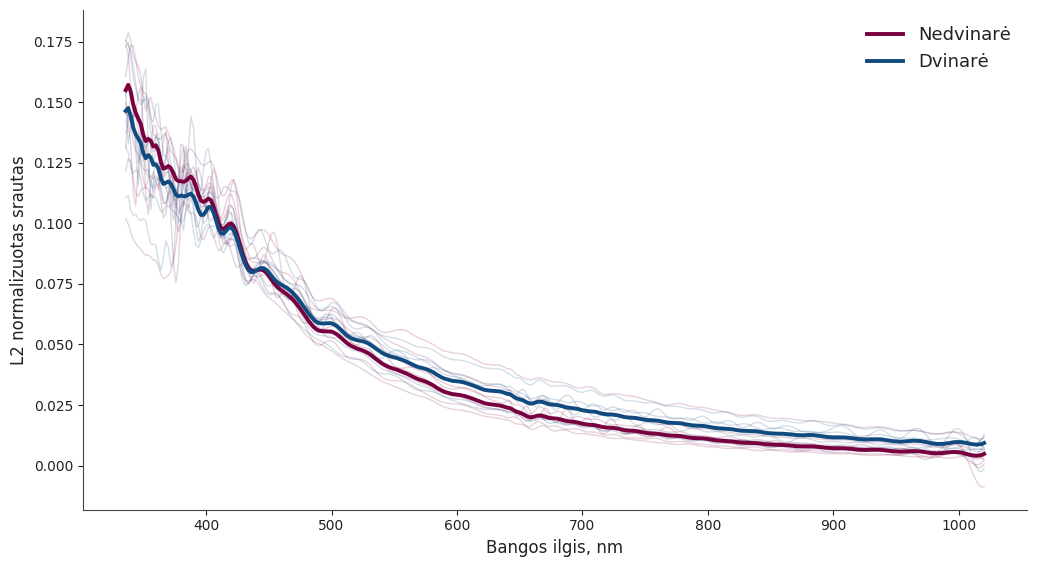

In [25]:
# Get row indices for both classes. These indices are reused in several plots and
# summary calculations below.
idx_binary = np.where(y == 1)[0]
idx_nonbinary = np.where(y == 0)[0]

# Randomly select a small number of spectra from each class for visualization.
rng = np.random.default_rng(RANDOM_STATE)
plot_binary = rng.choice(
    idx_binary,
    size=min(N_EXAMPLE_PER_CLASS, len(idx_binary)),
    replace=False,
)
plot_nonbinary = rng.choice(
    idx_nonbinary,
    size=min(N_EXAMPLE_PER_CLASS, len(idx_nonbinary)),
    replace=False,
)

# Compute class-wise mean spectra for the selected main representation and for
# both raw and L2-normalized data. Raw and L2 means are exported for comparison.
mean_binary_main = x_main[idx_binary].mean(axis=0)
mean_nonbinary_main = x_main[idx_nonbinary].mean(axis=0)

mean_binary_raw = x_raw[idx_binary].mean(axis=0)
mean_nonbinary_raw = x_raw[idx_nonbinary].mean(axis=0)

mean_binary_l2 = x_l2[idx_binary].mean(axis=0)
mean_nonbinary_l2 = x_l2[idx_nonbinary].mean(axis=0)
diff_l2 = mean_binary_l2 - mean_nonbinary_l2

fig, ax = plt.subplots(figsize=(10.5, 5.8))

# Plot individual non-binary spectra as light background curves.
for idx in plot_nonbinary:
    ax.plot(
        wavelengths,
        x_main[idx],
        alpha=0.18,
        linewidth=1.0,
        color=COLOR_SECONDARY,
    )

# Plot individual binary spectra as light background curves.
for idx in plot_binary:
    ax.plot(
        wavelengths,
        x_main[idx],
        alpha=0.18,
        linewidth=1.0,
        color=COLOR_PRIMARY,
    )

# Overlay class means with thicker lines to show the average class pattern.
ax.plot(
    wavelengths,
    mean_nonbinary_main,
    linewidth=2.8,
    color=COLOR_SECONDARY,
    label="Nedvinarė",
)
ax.plot(
    wavelengths,
    mean_binary_main,
    linewidth=2.8,
    color=COLOR_PRIMARY,
    label="Dvinarė",
)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel(
    "L2 normalizuotas srautas" if MAIN_REPRESENTATION == "l2" else "Srautas"
)
ax.legend(frameon=False, loc="best", fontsize=13)
apply_clean_axes(ax, add_grid=False)
show_and_save(fig, OUT_DIR / "fig_example_spectra.svg")



 ## 7. Functional mean and standard deviation

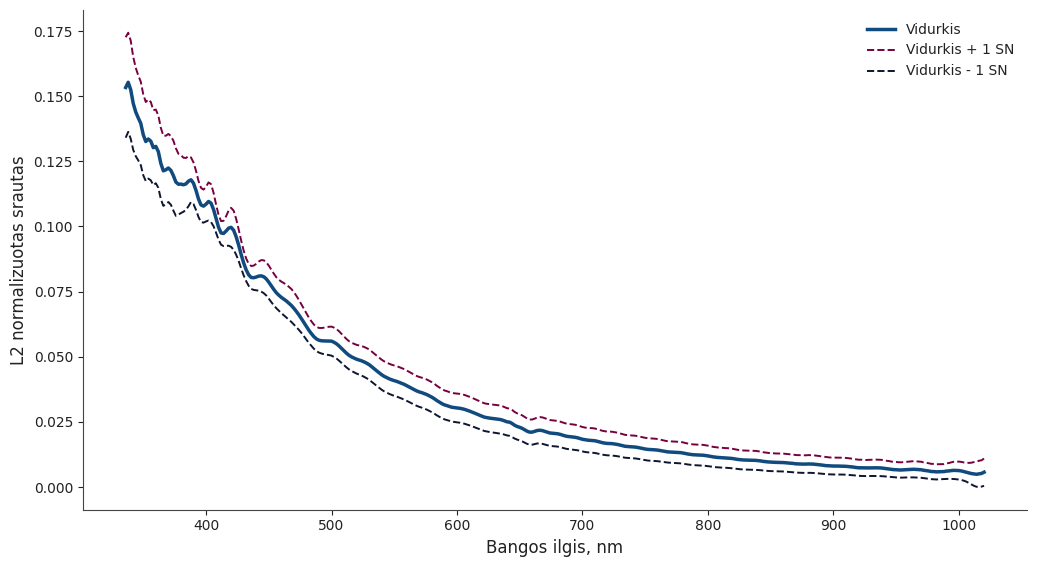

In [26]:
# Overall mean and standard deviation summarize the typical spectrum and the
# amount of variation across all objects.
mean_overall = x_main.mean(axis=0)
std_overall = x_main.std(axis=0, ddof=1)

fig, ax = plt.subplots(figsize=(10.5, 5.8))
ax.plot(
    wavelengths,
    mean_overall,
    linewidth=2.5,
    color=COLOR_PRIMARY,
    label="Vidurkis",
)
ax.plot(
    wavelengths,
    mean_overall + std_overall,
    linestyle="--",
    linewidth=1.4,
    color=COLOR_SECONDARY,
    label="Vidurkis + 1 SN",
)
ax.plot(
    wavelengths,
    mean_overall - std_overall,
    linestyle="--",
    linewidth=1.4,
    color=COLOR_DARK,
    label="Vidurkis - 1 SN",
)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel(
    "L2 normalizuotas srautas" if MAIN_REPRESENTATION == "l2" else "Srautas"
)
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
show_and_save(fig, OUT_DIR / "fig_mean_std_overall.svg")



 ## 8. Class-wise mean spectra and mean differences

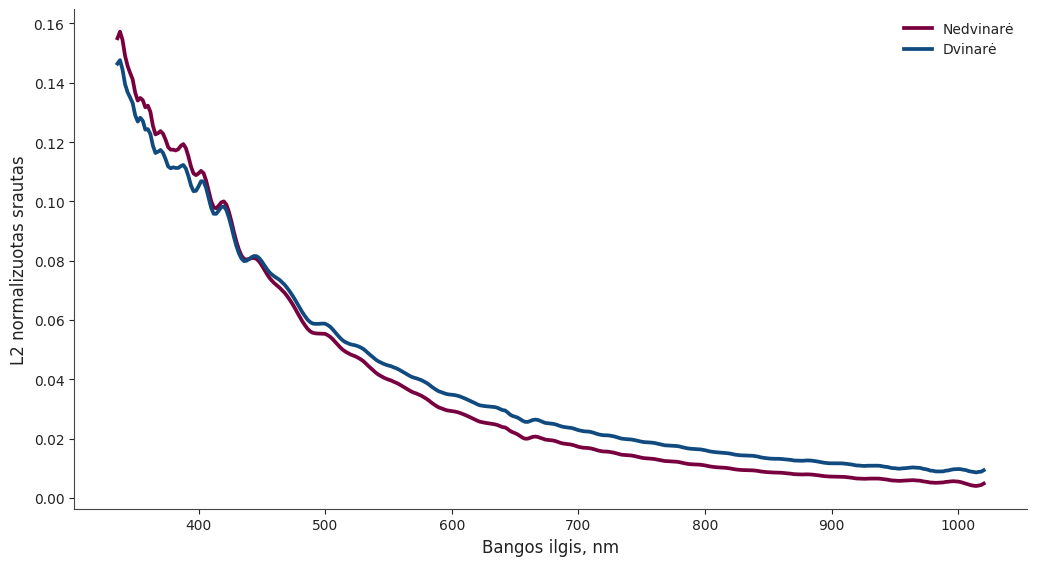

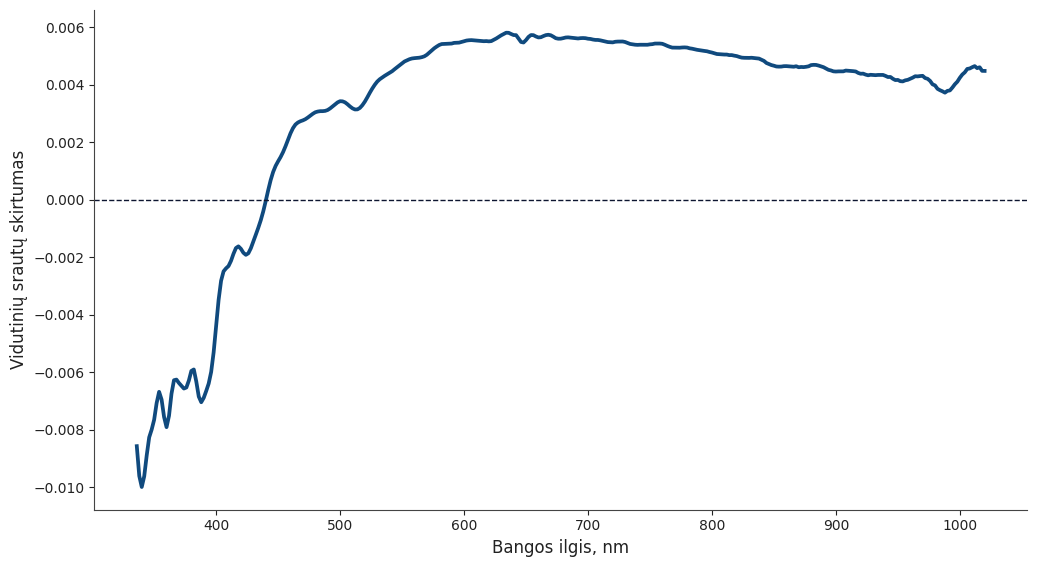

In [27]:
# Exportable table containing class-wise raw means, L2-normalized means, and the
# L2 mean difference curve used for interpretation.
class_mean_spectra = pd.DataFrame(
    {
        "wavelength": wavelengths,
        "mean_non_binary_raw": mean_nonbinary_raw,
        "mean_binary_raw": mean_binary_raw,
        "mean_non_binary_l2": mean_nonbinary_l2,
        "mean_binary_l2": mean_binary_l2,
        "difference_binary_minus_non_binary_l2": diff_l2,
    }
)

fig, ax = plt.subplots(figsize=(10.5, 5.8))
ax.plot(
    wavelengths,
    mean_nonbinary_main,
    linewidth=2.7,
    color=COLOR_SECONDARY,
    label="Nedvinarė",
)
ax.plot(
    wavelengths,
    mean_binary_main,
    linewidth=2.7,
    color=COLOR_PRIMARY,
    label="Dvinarė",
)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel(
    "L2 normalizuotas srautas" if MAIN_REPRESENTATION == "l2" else "Srautas"
)
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
show_and_save(fig, OUT_DIR / "fig_class_mean_spectra.svg")

fig, ax = plt.subplots(figsize=(10.5, 5.8))
ax.plot(wavelengths, diff_l2, linewidth=2.7, color=COLOR_PRIMARY)
ax.axhline(0, linestyle="--", linewidth=1.0, color=COLOR_DARK)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Vidutinių srautų skirtumas")
apply_clean_axes(ax, add_grid=False)
show_and_save(fig, OUT_DIR / "fig_class_mean_difference_l2.svg")



 ## 9. Wavelength-wise summary statistics

In [28]:
# Store wavelength-level summary values. These can be used later for tables,
# interpretation, or selecting informative wavelength regions.
wavelength_stats = pd.DataFrame(
    {
        "wavelength": wavelengths,
        "mean_overall_main": mean_overall,
        "std_overall_main": std_overall,
        "mean_binary_l2": mean_binary_l2,
        "mean_non_binary_l2": mean_nonbinary_l2,
        "abs_mean_diff_l2": np.abs(diff_l2),
    }
)

# Identify wavelengths with the strongest positive and negative class mean
# differences according to the L2-normalized spectra.
top_pos_l2 = class_mean_spectra.sort_values(
    "difference_binary_minus_non_binary_l2",
    ascending=False,
).head(10)
top_neg_l2 = class_mean_spectra.sort_values(
    "difference_binary_minus_non_binary_l2",
    ascending=True,
).head(10)

top_wavelength_differences = pd.concat(
    [
        top_pos_l2.assign(direction="binary_higher"),
        top_neg_l2.assign(direction="non_binary_higher"),
    ],
    ignore_index=True,
)

print("Top wavelengths where binary mean is higher (L2):")
display(top_pos_l2[["wavelength", "difference_binary_minus_non_binary_l2"]])

print("Top wavelengths where non-binary mean is higher (L2):")
display(top_neg_l2[["wavelength", "difference_binary_minus_non_binary_l2"]])



Top wavelengths where binary mean is higher (L2):


,wavelength,difference_binary_minus_non_binary_l2
149,634.0,0.005810
150,636.0,0.005807
151,638.0,0.005766
148,632.0,0.005764
166,668.0,0.005739
159,654.0,0.005729
152,640.0,0.005729
165,666.0,0.005726
153,642.0,0.005726
160,656.0,0.005725


Top wavelengths where non-binary mean is higher (L2):


,wavelength,difference_binary_minus_non_binary_l2
2,340.0,-0.009984
3,342.0,-0.009609
1,338.0,-0.009598
4,344.0,-0.008884
0,336.0,-0.008564
5,346.0,-0.008257
6,348.0,-0.007987
12,360.0,-0.007904
7,350.0,-0.007645
11,358.0,-0.007548


 ## 10. Correlation structure across wavelengths

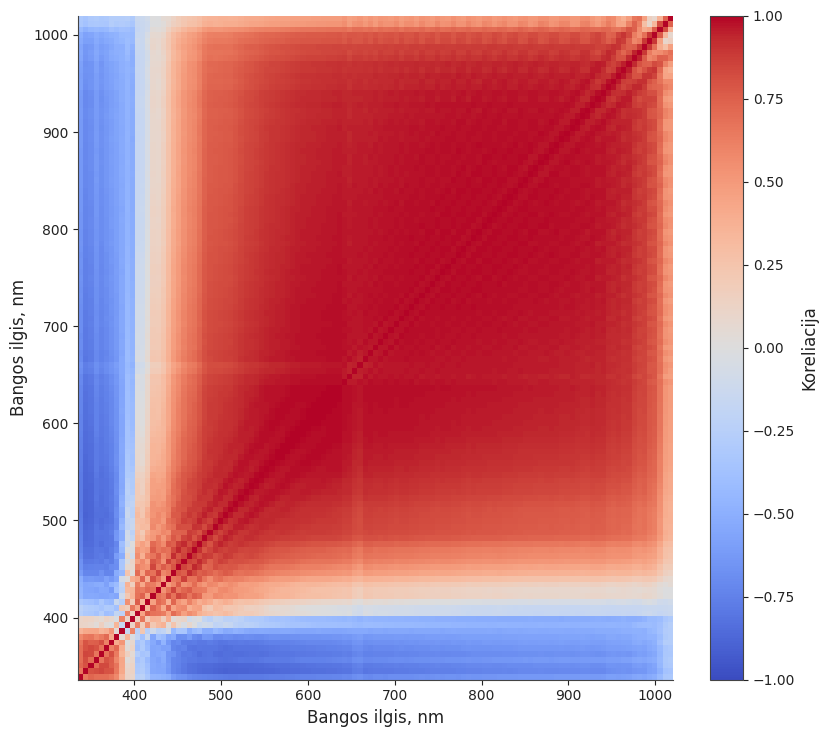

In [29]:
# Correlation matrix shows how strongly flux values at different wavelengths
# move together across objects.
corr_wavelength = np.corrcoef(x_main, rowvar=False)

# Downsample the correlation matrix for plotting to keep the heatmap readable.
corr_wavelength_plot = corr_wavelength[::CORR_PLOT_STEP, ::CORR_PLOT_STEP]
wavelengths_plot = wavelengths[::CORR_PLOT_STEP]

fig, ax = plt.subplots(figsize=(8.5, 7.5))
im = ax.imshow(
    corr_wavelength_plot,
    aspect="auto",
    origin="lower",
    interpolation="none",
    extent=[
        wavelengths_plot.min(),
        wavelengths_plot.max(),
        wavelengths_plot.min(),
        wavelengths_plot.max(),
    ],
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Koreliacija")

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Bangos ilgis, nm")
apply_clean_axes(ax, add_grid=False)
show_and_save(fig, OUT_DIR / "fig_correlation_heatmap.svg")



 ## 11. First and second derivatives

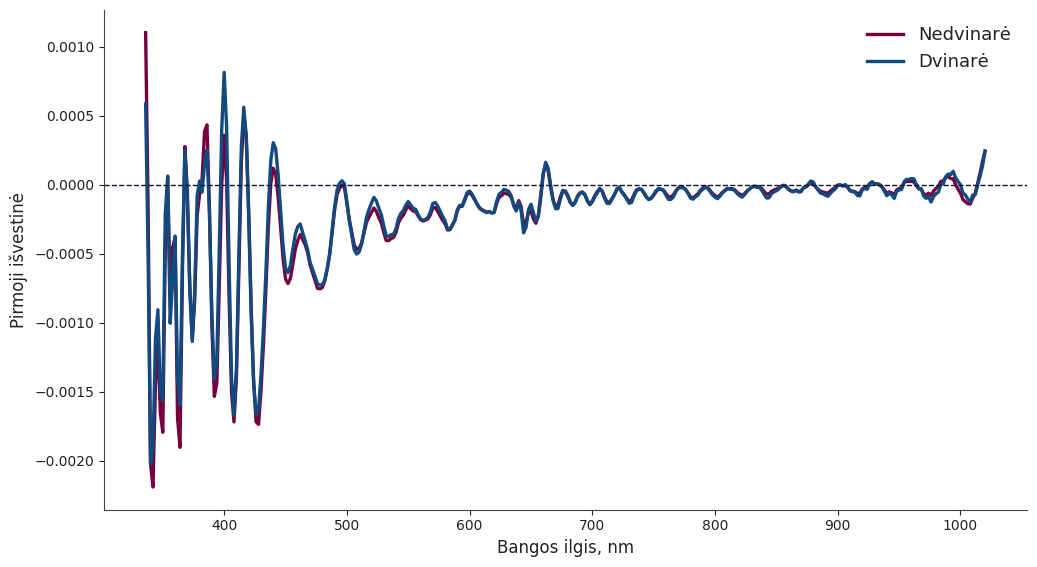

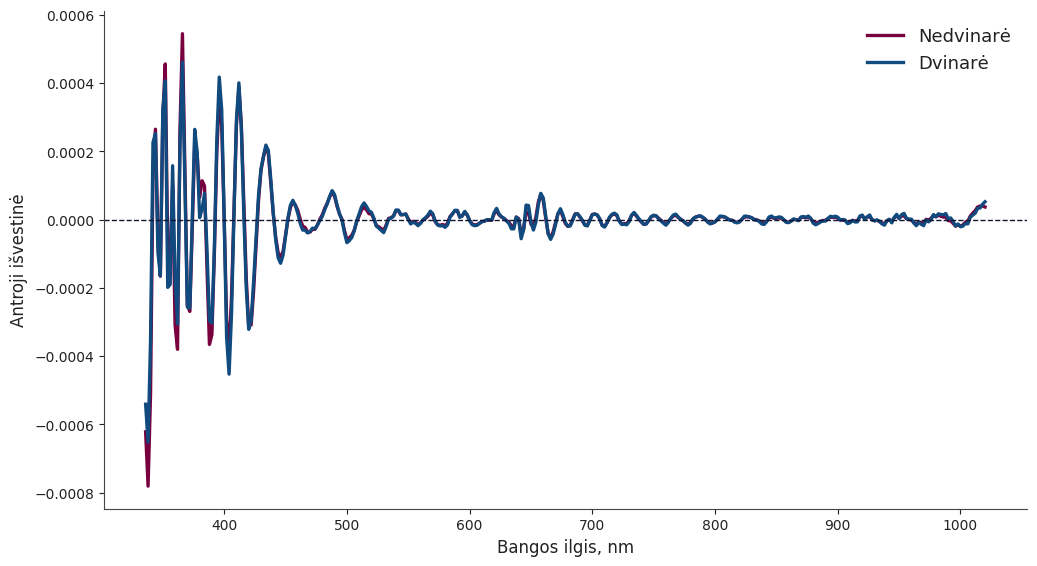

In [30]:
# Derivatives are exploratory descriptors of spectral shape. They are not used
# for modelling in this notebook.
d1 = compute_first_derivative(x_main, wavelengths)
d2 = compute_second_derivative(x_main, wavelengths)

# Compute class-wise derivative means to inspect whether class differences are
# visible in slopes or curvature.
mean_d1_binary = d1[idx_binary].mean(axis=0)
mean_d1_nonbinary = d1[idx_nonbinary].mean(axis=0)

mean_d2_binary = d2[idx_binary].mean(axis=0)
mean_d2_nonbinary = d2[idx_nonbinary].mean(axis=0)

derivative_summary_by_class = pd.DataFrame(
    {
        "wavelength": wavelengths,
        "mean_d1_non_binary": mean_d1_nonbinary,
        "mean_d1_binary": mean_d1_binary,
        "mean_d2_non_binary": mean_d2_nonbinary,
        "mean_d2_binary": mean_d2_binary,
    }
)

fig, ax = plt.subplots(figsize=(10.5, 5.8))
ax.plot(
    wavelengths,
    mean_d1_nonbinary,
    linewidth=2.4,
    color=COLOR_SECONDARY,
    label="Nedvinarė",
)
ax.plot(
    wavelengths,
    mean_d1_binary,
    linewidth=2.4,
    color=COLOR_PRIMARY,
    label="Dvinarė",
)
ax.axhline(0, linestyle="--", linewidth=1.0, color=COLOR_DARK)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Pirmoji išvestinė")
ax.legend(frameon=False, loc="best", fontsize=13)
apply_clean_axes(ax, add_grid=False)
show_and_save(fig, OUT_DIR / "fig_first_derivative_means.svg")

fig, ax = plt.subplots(figsize=(10.5, 5.8))
ax.plot(
    wavelengths,
    mean_d2_nonbinary,
    linewidth=2.4,
    color=COLOR_SECONDARY,
    label="Nedvinarė",
)
ax.plot(
    wavelengths,
    mean_d2_binary,
    linewidth=2.4,
    color=COLOR_PRIMARY,
    label="Dvinarė",
)
ax.axhline(0, linestyle="--", linewidth=1.0, color=COLOR_DARK)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Antroji išvestinė")
ax.legend(frameon=False, loc="best", fontsize=13)
apply_clean_axes(ax, add_grid=False)
show_and_save(fig, OUT_DIR / "fig_second_derivative_means.svg")



 ## 12. Simple global descriptors per spectrum

In [31]:
# Area under the curve gives a simple global flux descriptor for each spectrum.
area_under_curve = np.trapz(x_main, wavelengths, axis=1)

# Roughness descriptors summarize how much each spectrum changes across the
# wavelength grid. Larger values indicate less smooth spectra.
roughness_d1 = np.trapz(d1**2, wavelengths, axis=1)
roughness_d2 = np.trapz(d2**2, wavelengths, axis=1)

spectrum_descriptors = pd.DataFrame(
    {
        "source_id": source_ids,
        "y": y,
        "class_name": pd.Series(y).map({0: "non_binary", 1: "binary"}),
        "auc": area_under_curve,
        "roughness_d1": roughness_d1,
        "roughness_d2": roughness_d2,
    }
)

display(spectrum_descriptors.head())

# Summarize global descriptors by class to check whether classes differ in broad
# spectral shape characteristics.
global_descriptors_summary = (
    spectrum_descriptors.groupby("class_name")[[
        "auc",
        "roughness_d1",
        "roughness_d2",
    ]].agg(["mean", "std", "median"])
)

display(global_descriptors_summary)



,source_id,y,class_name,auc,roughness_d1,roughness_d2
0,1792620565667968,0,non_binary,24.608996,0.000653,0.000102
1,6052403489630720,0,non_binary,24.144017,0.000392,0.000048
2,10844075163628928,0,non_binary,28.351815,0.000502,0.000059
3,11015044926034816,0,non_binary,26.794635,0.001251,0.000164
4,11963171843658240,0,non_binary,27.884115,0.000695,0.000118


auc                      roughness_d1                      \
                 mean       std     median         mean       std    median   
class_name                                                                    
binary      27.493734  2.082781  27.511350     0.000864  0.001006  0.000546   
non_binary  25.333139  1.532462  25.076674     0.000719  0.000789  0.000457   

           roughness_d2                      
                   mean       std    median  
class_name                                   
binary         0.000134  0.000184  0.000074  
non_binary     0.000107  0.000150  0.000058

 ## 13. Save main table outputs

In [32]:
# Save all table outputs needed for thesis writing and later figures.
dataset_summary.to_csv(OUT_DIR / "dataset_summary.csv", index=False)
class_mean_spectra.to_csv(OUT_DIR / "class_mean_spectra.csv", index=False)
wavelength_stats.to_csv(OUT_DIR / "wavelength_stats.csv", index=False)
derivative_summary_by_class.to_csv(
    OUT_DIR / "derivative_summary_by_class.csv",
    index=False,
)
top_wavelength_differences.to_csv(
    OUT_DIR / "top_wavelength_differences.csv",
    index=False,
)
spectrum_descriptors.to_csv(OUT_DIR / "spectrum_descriptors.csv", index=False)

print("Saved main CSV outputs to:", OUT_DIR)
print("Saved figure outputs to:", OUT_DIR)



Saved main CSV outputs to: c:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\results\01_initial_data_exploration
Saved figure outputs to: c:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\results\01_initial_data_exploration


 ## 14. Initial functional insights

In [33]:
# Print the most important exploratory outputs again at the end of the notebook
# so they are easy to find after all figures and files have been generated.
print("Top wavelengths where binary mean is higher (L2):")
display(top_pos_l2[["wavelength", "difference_binary_minus_non_binary_l2"]])

print("Top wavelengths where non-binary mean is higher (L2):")
display(top_neg_l2[["wavelength", "difference_binary_minus_non_binary_l2"]])

print("Global descriptor summary by class:")
display(global_descriptors_summary)


Top wavelengths where binary mean is higher (L2):


,wavelength,difference_binary_minus_non_binary_l2
149,634.0,0.005810
150,636.0,0.005807
151,638.0,0.005766
148,632.0,0.005764
166,668.0,0.005739
159,654.0,0.005729
152,640.0,0.005729
165,666.0,0.005726
153,642.0,0.005726
160,656.0,0.005725


Top wavelengths where non-binary mean is higher (L2):


,wavelength,difference_binary_minus_non_binary_l2
2,340.0,-0.009984
3,342.0,-0.009609
1,338.0,-0.009598
4,344.0,-0.008884
0,336.0,-0.008564
5,346.0,-0.008257
6,348.0,-0.007987
12,360.0,-0.007904
7,350.0,-0.007645
11,358.0,-0.007548


Global descriptor summary by class:


auc                      roughness_d1                      \
                 mean       std     median         mean       std    median   
class_name                                                                    
binary      27.493734  2.082781  27.511350     0.000864  0.001006  0.000546   
non_binary  25.333139  1.532462  25.076674     0.000719  0.000789  0.000457   

           roughness_d2                      
                   mean       std    median  
class_name                                   
binary         0.000134  0.000184  0.000074  
non_binary     0.000107  0.000150  0.000058